# Week 7.3 - Self-supervised pretraining for label-efficient wake reconstruction
<!-- MIE690A article-aligned validation v4 -->

Scientific question: if we own many *unlabelled* wake fields and only a handful of
*labelled* ones, does pretraining a network on the unlabelled fields reduce the
number of labels needed for a new trajectory, and does it beat a classical method
that receives exactly the same information?

The protocol follows the recipe of MAPA (Tang, Spalding and Cogan, 2026: masked
autoencoding on intracranial recordings, then a label-efficiency curve for a new
subject) on the FlowMLLab lattice-Boltzmann cylinder wake: pretrain a masked
autoencoder (He et al., 2022) on two unlabelled trajectories, then measure error
against the number of labelled frames of a third trajectory. Gappy POD
(Everson and Sirovich, 1995) is the matched classical baseline.

Prerequisites: Weeks 5 and 7 (POD, the wake data) and Week 7.2 (validation-only
selection). Allow 90 minutes. CPU only; the long cells are the pretraining
(about 1 minute), the label-efficiency loop (about 4 minutes) and the budget
control (about 3 minutes) on a two-core machine; `QUICK = True` in the setup cell
cuts the total to about 3 minutes. Lecture: `lectures/week07_3_masked_pretraining.pdf`.

What this is not: the four trajectories are educational LBM runs at nearly the
same Reynolds number (90 to 110) on a 32 x 78 window, not grid-independent CFD,
and the target trajectory (Re = 110) was inspected in Weeks 5, 7 and 7.2. It is a
protocol demonstration with retained numbers, not a blind benchmark.
<!-- FLOWMLLAB_COLAB_LAUNCH_V1 -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ehsan-Roohi/FlowMLLab/blob/main/notebooks/week07_3/W7_3_Masked_Pretraining_Label_Efficiency.ipynb)


In [1]:
# FLOWMLLAB_COLAB_BOOTSTRAP_V1
# In Colab this cell obtains the complete repository and installs the tested package.
# In a local checkout it leaves the active environment and working directory unchanged.
from pathlib import Path as _FlowMLLabPath
import os as _flowmllab_os
import subprocess as _flowmllab_subprocess
import sys as _flowmllab_sys

if "google.colab" in _flowmllab_sys.modules or _flowmllab_os.environ.get("COLAB_RELEASE_TAG"):
    _flowmllab_root = _FlowMLLabPath("/content/FlowMLLab")
    if not (_flowmllab_root / ".git").is_dir():
        _flowmllab_subprocess.run(
            [
                "git", "clone", "--depth", "1",
                "https://github.com/Ehsan-Roohi/FlowMLLab.git", str(_flowmllab_root),
            ],
            check=True,
        )
    _flowmllab_subprocess.run(
        [
            _flowmllab_sys.executable, "-m", "pip", "install", "-q", "-e",
            f"{_flowmllab_root}[test]",
        ],
        check=True,
    )
    _flowmllab_notebook_dir = _flowmllab_root / "notebooks/week07_3"
    _flowmllab_os.chdir(_flowmllab_notebook_dir)
    for _flowmllab_path in (_flowmllab_root, _flowmllab_notebook_dir):
        if str(_flowmllab_path) not in _flowmllab_sys.path:
            _flowmllab_sys.path.insert(0, str(_flowmllab_path))
    print("FlowMLLab ready:", _flowmllab_root)

from pathlib import Path
import copy, hashlib, json, os, platform, sys, tempfile, time
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'flowmllab/masked_pretraining.py').is_file())
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from flowmllab import masked_pretraining as mp
from flowmllab.cylinder_ml import fit_pod

torch.set_num_threads(min(2, os.cpu_count() or 1))
QUICK = False            # True: one mask seed and four k values (about a quarter of the runtime)
WRITE_RESULTS = bool(os.environ.get('FLOWMLLAB_WRITE_RESULTS'))
RETAINED = ROOT / 'results/week07_3_pretraining'
OUT = RETAINED if WRITE_RESULTS else Path(tempfile.mkdtemp(prefix='flowmllab-week73-'))
OUT.mkdir(parents=True, exist_ok=True)
tracked = sorted(p for p in (ROOT / 'data/modal_labs').rglob('*.npz'))
before = {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in tracked}

fields = {re: mp.load_wake_field(ROOT, re) for re in mp.TRAJECTORIES}
layout = mp.PatchLayout()
cfg = mp.ProtocolConfig()
if QUICK:
    cfg = mp.ProtocolConfig(ks=(1, 4, 16, 64), seeds=(0,))
print({re: f.shape for re, f in fields.items()}, 'field =', mp.FIELD)
print('patch grid', layout.grid, '->', layout.n_patches, 'patches of', layout.py, 'x', layout.px, 'pixels')
print('outputs go to', OUT.name if not WRITE_RESULTS else RETAINED.relative_to(ROOT))


{90: (281, 32, 78), 100: (281, 32, 78), 105: (281, 32, 78), 110: (281, 32, 78)} field = v
patch grid (8, 13) -> 104 patches of 4 x 6 pixels
outputs go to results/week07_3_pretraining


## 1. Definitions before use

- **Label.** Here a label is a *complete* frame of the target trajectory: the full
  32 x 78 transverse-velocity field. A method that is "given k labelled frames"
  may read k complete frames of Re = 110 and nothing else from that trajectory.
- **Unlabelled data.** Complete frames of *other* trajectories (Re = 90 and 100).
  They are unlabelled with respect to the target: nothing about Re = 110 is in them.
  Self-supervised methods manufacture their own training signal from such data.
- **Patch.** A 4 x 6 block of pixels. The 32 x 78 window is an 8 x 13 grid of 104 patches.
- **Masking.** Hiding a random 75% of the patches of a frame (78 of 104). The
  *visible* patches are the input; the hidden ones are the prediction target.
- **Masked autoencoder (MAE).** A transformer *encoder* that reads only the
  visible patches and a small *decoder* that fills in the hidden ones. The
  training loss is the mean squared error on the hidden patches only.
- **Self-supervised pretraining.** Training the MAE on unlabelled frames with
  random masks. No label is used; the frames supervise themselves.
- **Zero-shot.** Applying the pretrained model to the target trajectory without
  any labelled frame of it.
- **Linear probe.** Freezing the pretrained encoder and fitting only a linear
  (ridge) map from its features to the full frame, using the k labelled frames.
- **Fine-tuning.** Continuing to train *all* weights of the pretrained model on
  the k labelled frames.
- **From scratch.** The same network, randomly initialised, trained on the k
  labelled frames only, with the same optimiser budget as fine-tuning.
- **Gappy POD.** The classical answer to the same completion task: fit a POD
  basis to complete frames, then for a masked frame solve a least-squares
  problem for the modal coefficients using the visible pixels only, and
  reconstruct the hidden pixels from the basis (Everson and Sirovich, 1995).
- **Matched baseline.** A baseline that sees exactly the same frames and the same
  visible pixels as the neural method. Without it, an improvement cannot be
  attributed to the method rather than to the information it received.
- **Label-efficiency curve.** Test error against k, the number of labelled frames.
  A pretrained method is more label-efficient if it reaches a given error with
  fewer labels. The *label saving* at a given error is the ratio of the labels
  the reference method needs to the labels the pretrained method needs.
- **Relative L2 error.** 100 x ||prediction - truth|| / ||truth||. We report it over
  the hidden pixels only (the quantity actually predicted); every method copies the
  visible pixels into its output first, so the full-frame error is always smaller.


## 2. Data and information contract

Four retained trajectories of the transverse velocity `v/U` on the 32 x 78 wake
window (`data/modal_labs/re*.npz`, 281 frames each, about 52 frames per shedding
period, hash-checked at the end of the notebook). Their roles are frozen before
any number is looked at:

| Trajectory | Role | Who may read it |
| --- | --- | --- |
| Re = 90, Re = 100 | unlabelled pretraining data | MAE pretraining; the transferred and pooled POD bases |
| Re = 105 | validation | every selection: POD rank, ridge strength, early stopping |
| Re = 110, frames `[0, 160)` | labelled pool | the k frames drawn per seed |
| Re = 110, frames `[210, 281)` | test | scoring only, with fixed random masks |

Frames `[160, 210)` of Re = 110 separate the pool from the test window, as in Week
7.2. The test masks hide 75% of the patches of every test frame; three mask
seeds also change which k frames are drawn from the pool. Selecting anything on
the test window is forbidden, so every hyperparameter is chosen on Re = 105.

Below: one Re = 110 test frame, the patch grid and a 75% mask. The 26 visible
patches are all that any method receives about that frame.


visible pixel fraction: 0.25


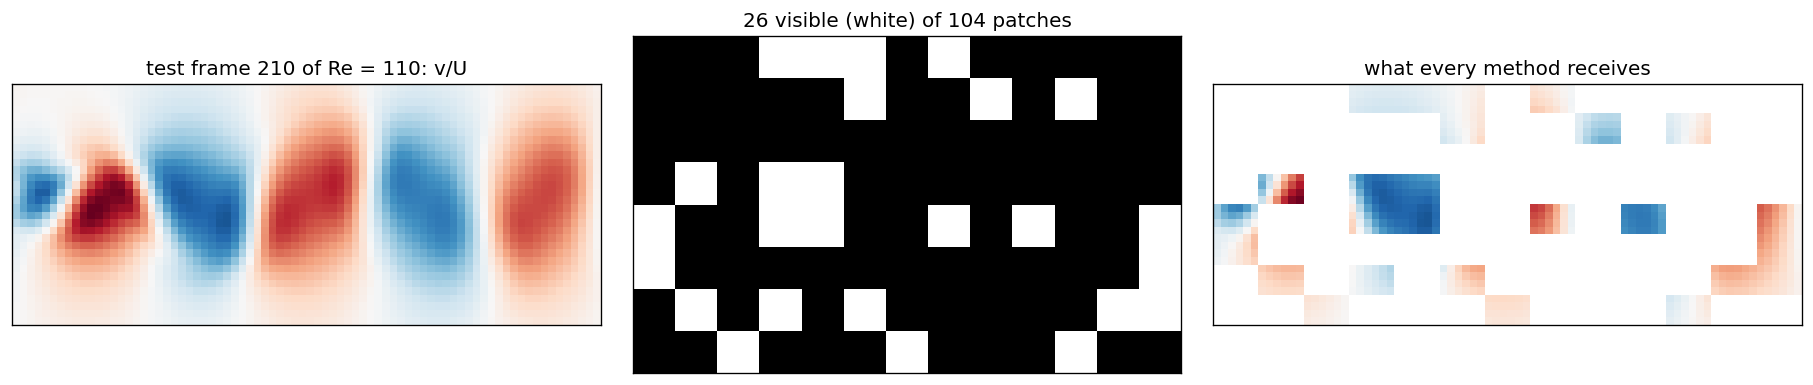

In [2]:
test_frames = fields[110][slice(*cfg.test_window)]
demo_visible = mp.random_patch_masks(1, layout.n_patches, cfg.mask_ratio, seed=2000)
demo_pixels = layout.pixel_mask(demo_visible)[0]
frame = test_frames[0]
vmax = float(np.abs(frame).max())
fig, axes = plt.subplots(1, 3, figsize=(15, 3.1), constrained_layout=True)
axes[0].imshow(frame, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='equal')
axes[0].set_title('test frame 210 of Re = 110: v/U')
axes[1].imshow(demo_visible.reshape(layout.grid), origin='lower', cmap='Greys_r', vmin=0, vmax=1, aspect='equal')
axes[1].set_title(f'{int(demo_visible.sum())} visible (white) of {layout.n_patches} patches')
axes[2].imshow(np.where(demo_pixels, frame, np.nan), origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='equal')
axes[2].set_title('what every method receives')
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.savefig(OUT / 'masking_example.png', dpi=150)
plt.show()
print('visible pixel fraction:', demo_pixels.mean())


## 3. The classical baseline: gappy POD

Write a complete frame as a vector $q \in \mathbb{R}^{2496}$ and a POD basis fitted
on complete frames as the mean $\bar q$ and modes $\Phi \in \mathbb{R}^{2496 \times r}$.
For a masked frame let $V$ be the index set of visible pixels. Gappy POD solves

$$\min_a \|\Phi_V a - (q_V - \bar q_V)\|^2 + \epsilon\|a\|^2, \qquad \hat q = \bar q + \Phi a,$$

with $\Phi_V$ the visible rows of the modes and a tiny ridge $\epsilon$ for
numerical safety. With 624 visible pixels and $r \le 64$ the system is
overdetermined ten times over, so the fit is a least-squares projection, not an
interpolation. The rank $r$ is the only choice and it is selected on Re = 105:
larger ranks represent more of the field but make the visible-pixel system
worse conditioned.

Two bases are used: the **transferred** basis from the unlabelled Re = 90 and
100 frames (zero labels of the target), and later a **target-only** basis from
the k labelled frames (rank at most k - 1) and a **pooled** basis from the
unlabelled frames plus the k labelled ones, the classical analogue of fine-tuning.


In [3]:
unlabelled = np.concatenate([fields[90], fields[100]])
validation = fields[105]
val_visible = mp.random_patch_masks(len(validation), layout.n_patches, cfg.mask_ratio, seed=1000)
val_pixels = layout.pixel_mask(val_visible)
val_patches = layout.patchify(validation)

t0 = time.perf_counter()
rank_transfer, rank_scores = mp.select_pod_rank(unlabelled, validation, val_pixels, cfg.rank_candidates)
basis_transfer = mp.fit_gappy_basis(unlabelled, rank_transfer)
print(f'transferred basis: rank {rank_transfer} selected on Re = 105 in {time.perf_counter() - t0:.1f} s')
display(pd.Series(rank_scores, name='Re105 masked error (%)').rename_axis('rank').to_frame().T.round(3))

test_masks = {seed: mp.random_patch_masks(len(test_frames), layout.n_patches, cfg.mask_ratio, seed=2000 + seed)
              for seed in cfg.seeds}
zero_shot = []
for seed, visible in test_masks.items():
    pixels = layout.pixel_mask(visible)
    prediction = mp.gappy_reconstruct(basis_transfer, test_frames, pixels)
    zero_shot.append({'method': 'pod_transfer', 'k': 0, 'seed': seed, **mp.score(prediction, test_frames, pixels)})
print('transferred gappy POD, zero-shot on the Re = 110 test window (masked-pixel relative L2, %):',
      [round(r['masked'], 2) for r in zero_shot])


transferred basis: rank 64 selected on Re = 105 in 1.0 s
transferred gappy POD, zero-shot on the Re = 110 test window (masked-pixel relative L2, %): [1.38, 1.42, 1.4]


rank,0,1,2,4,6,8,12,16,24,32,48,64
Re105 masked error (%),98.702,71.244,23.266,17.105,11.582,6.136,4.208,2.386,1.059,0.862,0.742,0.552


## 4. The masked autoencoder

Each visible patch (24 pixels) is embedded into a 64-dimensional token and given
a learned position embedding. A two-layer transformer encoder (4 heads, GELU,
pre-norm) attends over the 26 visible tokens only; it never sees a hidden patch,
so it cannot learn to copy. A one-layer decoder of width 32 receives the encoded
visible tokens plus a shared learned *mask token* at every hidden position, each
with its own position embedding, and a linear head predicts the 24 pixels of
every patch. The loss is the mean squared error over hidden patches only. The
model has about 90 thousand parameters.

Training uses AdamW (weight decay 0.05), a cosine learning-rate schedule from
2e-3, batches of 8 frames and a *fresh random mask for every frame at every
step*, so the 562 unlabelled frames yield an unlimited supply of training
problems. The masked loss on Re = 105 (with fixed masks) is evaluated once per
pass and the weights with the lowest validation loss are kept (early stopping).

Watch the loss curve: for the first few hundred steps the network predicts the
mean field (loss equal to the variance of `v`, the dashed line), then it breaks
through. A run stopped inside the plateau would look like a failed method.


MAE parameters: 90,168
  step    639  train 9.6311e-03  val 6.4333e-03     7.8 s
  step   1349  train 1.7541e-03  val 2.5680e-03    16.9 s
  step   2059  train 1.0663e-03  val 1.8182e-03    26.1 s
  step   2769  train 8.2375e-04  val 1.4488e-03    34.5 s
  step   3479  train 6.7142e-04  val 1.3461e-03    42.7 s
  step   4189  train 5.3553e-04  val 1.1607e-03    51.5 s
  step   4899  train 5.0136e-04  val 1.1690e-03    60.9 s
  step   5000  train 5.0301e-04  val 1.1700e-03    62.2 s
pretraining: 5000 steps in 63 s; weights restored from step 4189


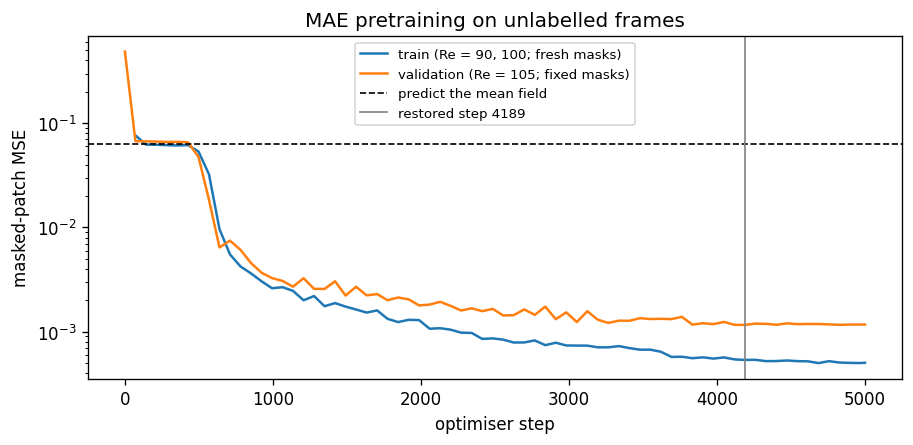

In [4]:
PRETRAIN_STEPS = 5000 if not QUICK else 2500
mae = mp.build_mae(layout, dim=64, depth=2, heads=4, decoder_dim=32, decoder_depth=1, seed=0)
n_parameters = sum(p.numel() for p in mae.parameters())
with torch.no_grad():
    probe_out = mae(torch.as_tensor(layout.patchify(test_frames[:2]), dtype=torch.float32),
                    torch.as_tensor(test_masks[cfg.seeds[0]][:2]))
assert probe_out.shape == (2, layout.n_patches, layout.patch_dim)
print(f'MAE parameters: {n_parameters:,}')

t0 = time.perf_counter()
history, best_step = mp.train_masked_model(mae, layout.patchify(unlabelled), layout, mask_ratio=cfg.mask_ratio,
                                           steps=PRETRAIN_STEPS, batch_size=8, lr=2e-3, seed=0,
                                           val_patches=val_patches, val_visible=val_visible, log_every=10)
pretrain_seconds = time.perf_counter() - t0
pretrained_state = copy.deepcopy(mae.state_dict())
print(f'pretraining: {PRETRAIN_STEPS} steps in {pretrain_seconds:.0f} s; weights restored from step {best_step}')

variance = float(np.var(unlabelled))
steps = [h['step'] for h in history]
fig, ax = plt.subplots(figsize=(7.5, 3.6), constrained_layout=True)
ax.semilogy(steps, [h['train_loss'] for h in history], label='train (Re = 90, 100; fresh masks)')   # NaN at step 0
ax.semilogy(steps, [h['val_loss'] for h in history], label='validation (Re = 105; fixed masks)')
ax.axhline(variance, color='k', ls='--', lw=1, label='predict the mean field')
ax.axvline(best_step, color='grey', lw=1, label=f'restored step {best_step}')
ax.set(xlabel='optimiser step', ylabel='masked-patch MSE', title='MAE pretraining on unlabelled frames')
ax.legend(fontsize=8)
fig.savefig(OUT / 'pretraining_loss.png', dpi=150)
plt.show()


## 5. Zero-shot reconstruction of the new trajectory

Neither the pretrained MAE nor the transferred POD basis has seen a single frame
of Re = 110. Both receive the same 26 visible patches of every test frame. The
first test frame (seed 0) is shown with both reconstructions and their absolute
error maps on a common scale; the table gives the masked-pixel error over all
71 test frames and the three mask seeds.


,masked error mean (%),sample SD (pp)
method,,
mae_zero_shot,17.621653,0.126889
pod_transfer,1.402507,0.018469


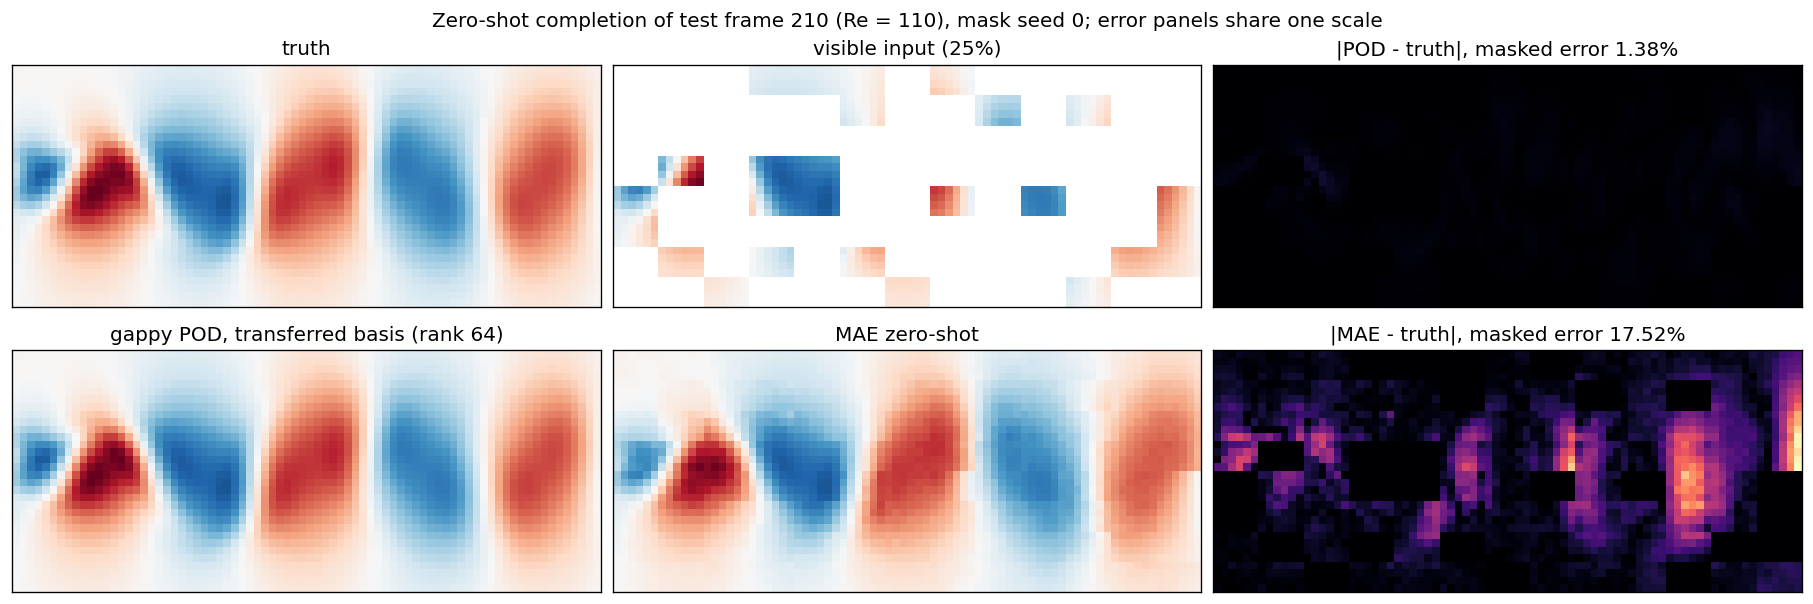

In [5]:
for seed, visible in test_masks.items():
    prediction = mp.predict_masked(mae, layout.patchify(test_frames), visible, layout)
    zero_shot.append({'method': 'mae_zero_shot', 'k': 0, 'seed': seed, **mp.score(prediction, test_frames, layout.pixel_mask(visible))})
zero_table = pd.DataFrame(zero_shot).groupby('method')['masked'].agg(['mean', 'std']).rename(
    columns={'mean': 'masked error mean (%)', 'std': 'sample SD (pp)'})
display(zero_table)

visible0 = test_masks[cfg.seeds[0]]
pixels0 = layout.pixel_mask(visible0)
pod0 = mp.fill_visible(mp.gappy_reconstruct(basis_transfer, test_frames, pixels0), test_frames, pixels0)
mae0 = mp.predict_masked(mae, layout.patchify(test_frames), visible0, layout)
i = 0
vmax = float(np.abs(test_frames[i]).max())
emax = float(max(np.abs(pod0[i] - test_frames[i]).max(), np.abs(mae0[i] - test_frames[i]).max()))
fig, axes = plt.subplots(2, 3, figsize=(15, 5), constrained_layout=True)
panels = [(test_frames[i], 'truth', vmax), (np.where(pixels0[i], test_frames[i], np.nan), 'visible input (25%)', vmax),
          (None, None, None),
          (pod0[i], f'gappy POD, transferred basis (rank {rank_transfer})', vmax), (mae0[i], 'MAE zero-shot', vmax)]
for ax, (array, title, limit) in zip(axes.ravel()[:5], panels):
    if array is None:
        ax.axis('off'); continue
    ax.imshow(array, origin='lower', cmap='RdBu_r', vmin=-limit, vmax=limit, aspect='equal'); ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 2].axis('on')
axes[0, 2].imshow(np.abs(pod0[i] - test_frames[i]), origin='lower', cmap='magma', vmin=0, vmax=emax, aspect='equal')
axes[0, 2].set_title(f'|POD - truth|, masked error {mp.score(pod0, test_frames, pixels0)["masked"]:.2f}%')
axes[1, 2].imshow(np.abs(mae0[i] - test_frames[i]), origin='lower', cmap='magma', vmin=0, vmax=emax, aspect='equal')
axes[1, 2].set_title(f'|MAE - truth|, masked error {mp.score(mae0, test_frames, pixels0)["masked"]:.2f}%')
for ax in (axes[0, 2], axes[1, 2]):
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Zero-shot completion of test frame 210 (Re = 110), mask seed 0; error panels share one scale')
fig.savefig(OUT / 'zero_shot_fields.png', dpi=150)
plt.show()


## 6. Using k labelled frames: five methods, one budget

For each mask seed and each k in {1, 2, 4, 8, 16, 32, 64, 128}, k complete frames
are drawn from the labelled pool `[0, 160)` of Re = 110 (evenly spread over the
pool for k <= 8, random otherwise) and every method is refitted:

| Method | Uses unlabelled frames | Uses the k labels | What is fitted |
| --- | --- | --- | --- |
| `pod_target` | no | yes | POD basis of the k frames (rank <= k - 1, chosen on Re = 105; k = 1 gives the mean field) |
| `pod_pooled` | yes | yes | POD basis of the 562 unlabelled frames plus the k frames (rank chosen on Re = 105) |
| `mae_probe` | yes (pretrained) | yes | ridge readout from the visible-token-pooled mean of visible encoder tokens to the full frame; 8 random masks per labelled frame; ridge strength chosen on Re = 105 |
| `mae_scratch` | no | yes | the MAE architecture from random weights, 300 AdamW steps on the k frames with fresh masks, early stopping on Re = 105 |
| `mae_finetune` | yes (pretrained) | yes | the pretrained MAE, the same 300 steps at a lower learning rate (5e-4), early stopping on Re = 105 |

`mae_scratch` and `mae_finetune` receive identical labelled data and identical
downstream compute; the only difference is the starting point. A separate
control at the end gives the from-scratch model the full pretraining budget on
the 128 labelled frames, to answer the objection that it merely needed longer.

Errors are averaged over the 71 test frames of each seed; the curve shows the
mean and sample SD over the three seeds. The seeds change the masks and the
drawn frames of one CFD trajectory; they are not independent flows.


In [6]:
pool = np.arange(*cfg.label_pool)
records = list(zero_shot)
timings = {}
T0 = time.perf_counter()
for seed in cfg.seeds:
    visible = test_masks[seed]
    pixels = layout.pixel_mask(visible)
    test_patches = layout.patchify(test_frames)
    test_features = mp.encoder_features(mae, test_patches, visible, pooling='visible_mean')
    for k in cfg.ks:
        labelled = fields[110][mp.sample_labelled_frames(pool, k, seed=100 * seed + k)]
        t = time.perf_counter()
        rank, _ = mp.select_pod_rank(labelled, validation, val_pixels, cfg.rank_candidates)
        prediction = mp.gappy_reconstruct(mp.fit_gappy_basis(labelled, rank), test_frames, pixels)
        records.append({'method': 'pod_target', 'k': k, 'seed': seed, 'rank': rank, **mp.score(prediction, test_frames, pixels)})
        timings.setdefault('pod_target', []).append(time.perf_counter() - t)

        t = time.perf_counter()
        pooled = np.concatenate([unlabelled, labelled])
        rank, _ = mp.select_pod_rank(pooled, validation, val_pixels, cfg.rank_candidates)
        prediction = mp.gappy_reconstruct(mp.fit_gappy_basis(pooled, rank), test_frames, pixels)
        records.append({'method': 'pod_pooled', 'k': k, 'seed': seed, 'rank': rank, **mp.score(prediction, test_frames, pixels)})
        timings.setdefault('pod_pooled', []).append(time.perf_counter() - t)

        t = time.perf_counter()
        readout, alpha, _ = mp.fit_ridge_probe(mae, labelled, layout, mask_ratio=cfg.mask_ratio,
                                               copies=cfg.masks_per_labelled_frame, seed=300 + seed,
                                               val_frames=validation, val_visible=val_visible, alphas=cfg.alpha_candidates)
        prediction = readout.predict(test_features).reshape(test_frames.shape)
        records.append({'method': 'mae_probe', 'k': k, 'seed': seed, 'alpha': alpha, **mp.score(prediction, test_frames, pixels)})
        timings.setdefault('mae_probe', []).append(time.perf_counter() - t)

        t = time.perf_counter()
        scratch = mp.build_mae(layout, seed=seed)
        _, step = mp.train_downstream(scratch, labelled, layout, cfg, lr=cfg.scratch_lr, seed=400 + seed,
                                      val_patches=val_patches, val_visible=val_visible)
        prediction = mp.predict_masked(scratch, test_patches, visible, layout)
        records.append({'method': 'mae_scratch', 'k': k, 'seed': seed, 'best_step': step, **mp.score(prediction, test_frames, pixels)})
        timings.setdefault('mae_scratch', []).append(time.perf_counter() - t)

        t = time.perf_counter()
        tuned = mp.build_mae(layout, seed=seed)
        tuned.load_state_dict(pretrained_state)
        _, step = mp.train_downstream(tuned, labelled, layout, cfg, lr=cfg.finetune_lr, seed=500 + seed,
                                      val_patches=val_patches, val_visible=val_visible)
        prediction = mp.predict_masked(tuned, test_patches, visible, layout)
        records.append({'method': 'mae_finetune', 'k': k, 'seed': seed, 'best_step': step, **mp.score(prediction, test_frames, pixels)})
        timings.setdefault('mae_finetune', []).append(time.perf_counter() - t)
        print(f'seed {seed}  k {k:3d}  ' + '  '.join(f"{r['method']} {r['masked']:6.2f}%" for r in records[-5:])
              + f'   {time.perf_counter() - T0:5.0f} s', flush=True)
protocol_seconds = time.perf_counter() - T0
print({m: f'{sum(v):.0f} s' for m, v in timings.items()})


seed 0  k   1  pod_target 135.69%  pod_pooled   1.31%  mae_probe 135.69%  mae_scratch 106.34%  mae_finetune  17.52%       6 s
seed 0  k   2  pod_target  80.90%  pod_pooled   1.31%  mae_probe  79.61%  mae_scratch 100.26%  mae_finetune  17.52%      11 s
seed 0  k   4  pod_target  24.81%  pod_pooled   1.16%  mae_probe  22.91%  mae_scratch  99.70%  mae_finetune  10.17%      18 s
seed 0  k   8  pod_target   5.26%  pod_pooled   0.94%  mae_probe  14.61%  mae_scratch  99.66%  mae_finetune   8.37%      26 s
seed 0  k  16  pod_target   1.57%  pod_pooled   0.63%  mae_probe  11.47%  mae_scratch  99.13%  mae_finetune   8.17%      35 s
seed 0  k  32  pod_target   0.57%  pod_pooled   0.32%  mae_probe   9.76%  mae_scratch 100.30%  mae_finetune   8.38%      44 s
seed 0  k  64  pod_target   0.04%  pod_pooled   0.18%  mae_probe   9.13%  mae_scratch  99.97%  mae_finetune   7.96%      54 s
seed 0  k 128  pod_target   0.02%  pod_pooled   0.15%  mae_probe   8.82%  mae_scratch  99.88%  mae_finetune   7.91%   

## 7. The label-efficiency curve

The figure is the analogue of MAPA's main result: masked-pixel error against the
number of labelled frames, one curve per method, with the two zero-shot methods
as horizontal lines. Read it in three steps: (1) compare `mae_finetune` with
`mae_scratch` (does pretraining help the *network*?); (2) compare `mae_finetune`
with `pod_pooled` (does the network beat the classical method with the same
information?); (3) find the label saving: how many labels does the from-scratch
model need to match what the pretrained one does with its smallest k.


Label saving: the smallest k at which the reference method reaches the pretrained method's error


,mae_finetune,mae_probe,mae_scratch,pod_pooled,pod_target
k labelled frames,,,,,
1,17.62 +/- 0.13,141.36 +/- 5.47,114.74 +/- 19.71,1.36 +/- 0.04,141.36 +/- 5.47
2,17.62 +/- 0.13,75.27 +/- 3.75,99.86 +/- 0.38,1.30 +/- 0.01,76.11 +/- 4.15
4,10.03 +/- 0.38,22.94 +/- 0.62,99.39 +/- 0.58,1.15 +/- 0.03,24.85 +/- 0.25
8,7.95 +/- 0.38,13.65 +/- 0.93,99.78 +/- 0.16,0.90 +/- 0.03,5.30 +/- 0.08
16,8.51 +/- 0.82,16.12 +/- 7.15,100.15 +/- 0.91,0.71 +/- 0.11,5.14 +/- 6.18
32,7.79 +/- 0.51,9.12 +/- 0.56,100.33 +/- 0.27,0.28 +/- 0.04,0.61 +/- 0.14
64,7.67 +/- 0.25,8.11 +/- 0.91,99.99 +/- 0.27,0.18 +/- 0.02,0.04 +/- 0.00
128,7.51 +/- 0.34,7.76 +/- 0.96,99.72 +/- 0.28,0.15 +/- 0.01,0.02 +/- 0.00


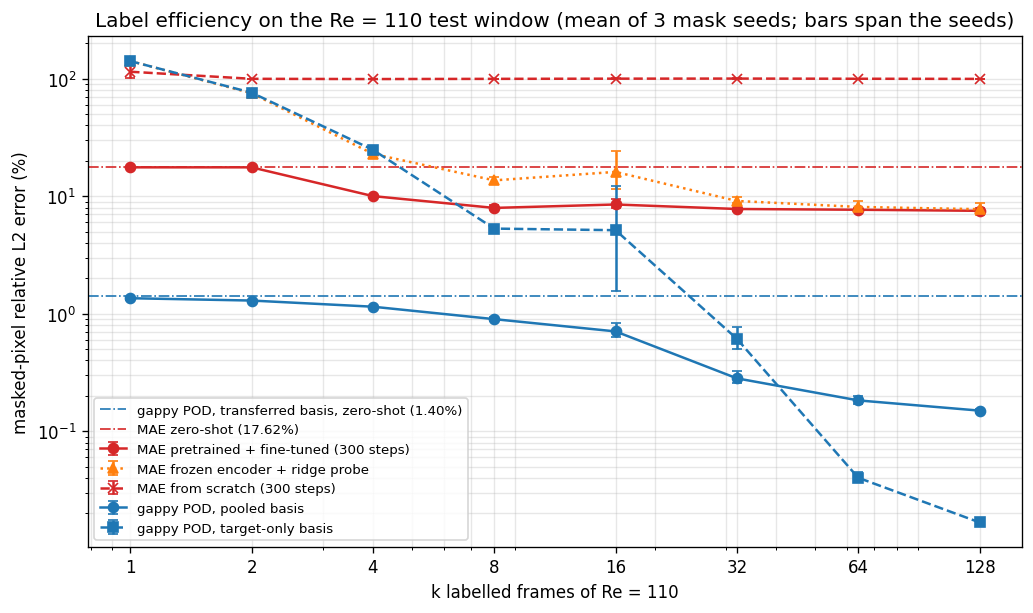

pretrained error (%)  ... label saving
comparison                  k (pretrained)                        ...             
mae_finetune vs mae_scratch 1                              17.62  ...  not reached
                            2                              17.62  ...  not reached
                            4                              10.03  ...  not reached
                            8                               7.95  ...  not reached
                            16                              8.51  ...  not reached
                            32                              7.79  ...  not reached
                            64                              7.67  ...  not reached
                            128                             7.51  ...  not reached
mae_finetune vs pod_target  1                              17.62  ...           8x
                            2                              17.62  ...           4x
                            4                              10.03  ...           2x
                            8                               7.95  ...           1x
                            16                              8.51  ...           0x
                            32                              7.79  ...           0x
                            64                              7.67  ...           0x
                            128                             7.51  ...           0x
pod_pooled vs pod_target    1                               1.36  ...          32x
                            2                               1.30  ...          16x
                            4                               1.15  ...           8x
                            8                               0.90  ...           4x
                            16                              0.71  ...           2x
                            32                              0.28  ...           2x
                            64                              0.18  ...           1x
                            128                             0.15  ...           0x

[24 rows x 3 columns]

In [7]:
curves = mp.summarize_curves([r for r in records if r['k'] > 0])
zero = {m: float(np.mean([r['masked'] for r in records if r['method'] == m])) for m in ('pod_transfer', 'mae_zero_shot')}
table = pd.DataFrame({m: {k: f"{v['mean']:.2f} +/- {v['std']:.2f}" for k, v in c.items()} for m, c in curves.items()})
table.index.name = 'k labelled frames'
display(table)

labels = {'pod_target': 'gappy POD, target-only basis', 'pod_pooled': 'gappy POD, pooled basis',
          'mae_probe': 'MAE frozen encoder + ridge probe', 'mae_scratch': 'MAE from scratch (300 steps)',
          'mae_finetune': 'MAE pretrained + fine-tuned (300 steps)'}
styles = {'pod_target': ('tab:blue', 's', '--'), 'pod_pooled': ('tab:blue', 'o', '-'), 'mae_probe': ('tab:orange', '^', ':'),
          'mae_scratch': ('tab:red', 'x', '--'), 'mae_finetune': ('tab:red', 'o', '-')}
fig, ax = plt.subplots(figsize=(8.5, 5), constrained_layout=True)
for method, curve in curves.items():
    ks = sorted(curve)
    color, marker, ls = styles[method]
    means = np.array([curve[k]['mean'] for k in ks])
    lower = means - np.array([curve[k]['min'] for k in ks])
    upper = np.array([curve[k]['max'] for k in ks]) - means
    ax.errorbar(ks, means, yerr=[lower, upper], color=color, marker=marker, ls=ls, capsize=3, label=labels[method])
ax.axhline(zero['pod_transfer'], color='tab:blue', lw=1, ls='-.', label=f"gappy POD, transferred basis, zero-shot ({zero['pod_transfer']:.2f}%)")
ax.axhline(zero['mae_zero_shot'], color='tab:red', lw=1, ls='-.', label=f"MAE zero-shot ({zero['mae_zero_shot']:.2f}%)")
ax.set(xscale='log', yscale='log', xlabel='k labelled frames of Re = 110', ylabel='masked-pixel relative L2 error (%)',
       title='Label efficiency on the Re = 110 test window (mean of 3 mask seeds; bars span the seeds)')
ax.set_xticks(list(cfg.ks)); ax.set_xticklabels([str(k) for k in cfg.ks])
ax.grid(True, which='both', alpha=.3); ax.legend(fontsize=8, loc='lower left')
fig.savefig(OUT / 'label_efficiency.png', dpi=150)
plt.show()

mean_curve = lambda m: {k: v['mean'] for k, v in curves[m].items()}
comparisons = [('mae_finetune', 'mae_scratch'), ('mae_finetune', 'pod_target'), ('pod_pooled', 'pod_target')]
savings = {f'{pretrained}_vs_{reference}': mp.label_saving(mean_curve(reference), mean_curve(pretrained))
           for pretrained, reference in comparisons}
saving_rows = []
for pretrained, reference in comparisons:
    s = savings[f'{pretrained}_vs_{reference}']
    for k, match in s['matches'].items():
        saving_rows.append({'comparison': f'{pretrained} vs {reference}', 'k (pretrained)': k,
                            'pretrained error (%)': round(curves[pretrained][k]['mean'], 2),
                            'reference k needed': match if match is not None else f'> {max(cfg.ks)}',
                            'label saving': f'{s["saving"][k]:.0f}x' if s['saving'][k] is not None else 'not reached'})
print('Label saving: the smallest k at which the reference method reaches the pretrained method\'s error')
display(pd.DataFrame(saving_rows).set_index(['comparison', 'k (pretrained)']))


## 8. Budget control: is pretraining just "more steps"?

`mae_scratch` above received 300 steps, and at that budget it never leaves the
mean-field plateau. The fair objection is that it needed as many steps as
pretraining. The control below trains the architecture from scratch on the
labelled frames of seed 0 for the *full pretraining budget* at k = 2, 8 and 128
and places the results next to the 300-step fine-tuned model on the same frames.
It uses far more labelled compute than any other entry; if it still cannot match
the fine-tuned model at small k, the advantage is the pretraining, not the steps.


In [8]:
seed0 = cfg.seeds[0]
control_ks = (2, 8, 128) if not QUICK else (4,)     # every control k must also be in cfg.ks
controls = []
for k in control_ks:
    labelled = fields[110][mp.sample_labelled_frames(pool, k, seed=100 * seed0 + k)]   # the same frames as the loop
    t0 = time.perf_counter()
    control = mp.build_mae(layout, seed=seed0)
    _, control_step = mp.train_masked_model(control, layout.patchify(labelled), layout, mask_ratio=cfg.mask_ratio,
                                            steps=PRETRAIN_STEPS, batch_size=8, lr=2e-3, seed=600 + k,
                                            val_patches=val_patches, val_visible=val_visible, val_every=50)
    result = mp.score(mp.predict_masked(control, layout.patchify(test_frames), test_masks[seed0], layout),
                      test_frames, layout.pixel_mask(test_masks[seed0]))
    finetuned = [r['masked'] for r in records if r['method'] == 'mae_finetune' and r['k'] == k and r['seed'] == seed0]
    controls.append({'k': k, 'seed': seed0, 'steps': PRETRAIN_STEPS, 'best_step': control_step,
                     'seconds': time.perf_counter() - t0, **result,
                     'finetune_300_steps_masked': finetuned[0] if finetuned else None})
    print(f"k = {k:3d}: from scratch, {PRETRAIN_STEPS} steps -> {result['masked']:6.2f}%  (restored step {control_step}, "
          f"{controls[-1]['seconds']:.0f} s);  pretrained + {cfg.downstream_steps} steps -> "
          f"{controls[-1]['finetune_300_steps_masked']:.2f}%" if finetuned else '', flush=True)
print(f"pretrained, zero labels (seed {seed0}): "
      f"{[r['masked'] for r in records if r['method'] == 'mae_zero_shot' and r['seed'] == seed0][0]:.2f}%")


k =   2: from scratch, 5000 steps ->  94.37%  (restored step 1050, 38 s);  pretrained + 300 steps -> 17.52%
k =   8: from scratch, 5000 steps ->   8.67%  (restored step 4250, 63 s);  pretrained + 300 steps -> 8.37%
k = 128: from scratch, 5000 steps ->   6.29%  (restored step 4600, 64 s);  pretrained + 300 steps -> 7.91%
pretrained, zero labels (seed 0): 17.52%


## 9. Reading the result honestly

Three findings, each bounded by the data it was measured on:

1. **Pretraining helps the network, most where labels are fewest.** With the
   same labelled frames and the same downstream budget, the fine-tuned model is
   never worse than its zero-shot starting point (early stopping may keep the
   pretrained weights), improves on it from k = 4 (about 10%) and settles near
   8% from k = 8 upwards, while the from-scratch model is still predicting the
   mean field (about 100%) at every k; the
   label-saving table above is the honest summary. The budget control sharpens
   the claim rather than overturning it: with the full pretraining budget on
   the target frames, the from-scratch model still fails at k = 2, comes within
   about a percentage point at k = 8, and at k = 128 is at least as good as the
   300-step fine-tuned model. The benefit of pretraining is concentrated in the
   low-label regime, which is the regime MAPA is about; with enough labels and
   enough compute, the unlabelled trajectories add nothing on this data.
2. **The classical method wins.** Gappy POD with a transferred basis, zero labels,
   is already an order of magnitude more accurate than the fine-tuned network,
   and the pooled basis improves further with every labelled frame. The wake at
   Re = 90 to 110 is periodic and low-rank: 64 modes fitted on other Reynolds
   numbers span the target field almost exactly, and 624 visible pixels
   overdetermine the coefficients. A transformer with 90 thousand weights and
   562 training frames cannot beat a subspace that is nearly the truth.
3. **The frozen probe is weaker than the decoder.** The linear readout from
   frozen features is worse than the pretrained decoder for small k, because the
   readout must be linear in features that already have zeros wherever a patch
   is hidden; the decoder is exactly the nonlinear map the pretraining built.

When does the pretraining recipe pay off? When the data are not low-rank, when
no matched linear baseline exists, or when the downstream label is not the
field itself (MAPA decodes behaviour and speech from the recordings). The
exercises ask you to move this experiment towards those conditions rather than
to declare a winner on this one.

Limits of the evidence: educational LBM at 12 lattice nodes per diameter;
four trajectories at nearly the same Reynolds number; the target trajectory
was inspected in earlier weeks; three mask seeds of one trajectory, not
independent flows; CPU-sized models and budgets.


In [9]:
after = {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in tracked}
assert after == before, 'the notebook must not modify the retained wake data'
metrics = {
    'protocol': {'field': mp.FIELD, 'mask_ratio': cfg.mask_ratio, 'patch': [layout.py, layout.px], 'patch_grid': list(layout.grid),
                 'label_pool': list(cfg.label_pool), 'test_window': list(cfg.test_window), 'ks': list(cfg.ks), 'seeds': list(cfg.seeds),
                 'pretraining_trajectories': [90, 100], 'validation_trajectory': 105, 'target_trajectory': 110,
                 'rank_candidates': list(cfg.rank_candidates), 'alpha_candidates': list(cfg.alpha_candidates),
                 'masks_per_labelled_frame': cfg.masks_per_labelled_frame, 'downstream_steps': cfg.downstream_steps,
                 'downstream_batch': cfg.downstream_batch, 'scratch_lr': cfg.scratch_lr, 'finetune_lr': cfg.finetune_lr,
                 'pretrain_steps': PRETRAIN_STEPS, 'pretrain_batch': 8, 'pretrain_lr': 2e-3, 'quick': QUICK},
    'model': {'parameters': n_parameters, 'dim': 64, 'depth': 2, 'heads': 4, 'decoder_dim': 32, 'decoder_depth': 1},
    'pretraining': {'best_step': best_step, 'seconds': pretrain_seconds, 'history': history, 'variance_of_v': variance},
    'transferred_pod': {'rank': rank_transfer, 'validation_scores': {str(k): v for k, v in rank_scores.items()}},
    'zero_shot': zero, 'curves': {m: {str(k): v for k, v in c.items()} for m, c in curves.items()},
    'records': records, 'label_saving': savings,
    'scratch_controls': controls,
    'timings_seconds': {m: float(sum(v)) for m, v in timings.items()} | {'protocol_total': protocol_seconds},
    'environment': {'python': platform.python_version(), 'numpy': np.__version__, 'torch': torch.__version__,
                    'threads': torch.get_num_threads(), 'platform': platform.platform()},
    'source_hashes': {f'data/modal_labs/{name}': digest for name, digest in after.items()},
}
mp.write_json(OUT / 'metrics.json', metrics)
print('written:', sorted(p.name for p in OUT.iterdir()))

retained_path = RETAINED / 'metrics.json'
if retained_path.is_file() and not WRITE_RESULTS:
    retained = json.loads(retained_path.read_text())
    rows = []
    for method, curve in retained['curves'].items():
        for k, v in curve.items():
            fresh = curves.get(method, {}).get(int(k))
            if fresh:
                rows.append({'method': method, 'k': int(k), 'retained (%)': round(v['mean'], 2), 'this run (%)': round(fresh['mean'], 2)})
    print('Your run against the retained evidence (differences come from CPU arithmetic, thread count and QUICK):')
    display(pd.DataFrame(rows).pivot(index='k', columns='method', values=['retained (%)', 'this run (%)']))
print('PASS: retained data unchanged; outputs in', OUT.relative_to(ROOT) if WRITE_RESULTS else OUT.name)


written: ['README.md', 'label_efficiency.png', 'masking_example.png', 'metrics.json', 'pretraining_loss.png', 'zero_shot_fields.png']
PASS: retained data unchanged; outputs in results/week07_3_pretraining


## 10. Exercises

1. **Structured masks.** Replace the random patch mask by a contiguous hidden
   block (for example the downstream half of the window). Which method degrades
   more, and why does the least-squares argument of Section 3 change?
2. **A harder downstream label.** Use the masked `v` field as input but the
   full `omega` field (also in the archives) as the label. Build the matched
   classical baseline (a linear map from gappy-POD coefficients of `v` to
   `omega`, fitted on the k frames) and redraw the curve.
3. **Noise.** Add Gaussian noise of 10% of the field RMS to the visible pixels,
   as in Week 7.2. Reselect the POD rank and the ridge strength on Re = 105
   and report which method is more robust.
4. **Budget fairness.** Give `mae_scratch` 1000 and 3000 steps at every k and
   plot the family of curves. At what budget does it catch the zero-shot model,
   and does it ever catch `mae_finetune`?
5. **Falsification.** Write down, before running anything, the observation that
   would make you conclude that pretraining does *not* help on this data. Then
   check whether the retained evidence contains it.

## References

- K. He, X. Chen, S. Xie, Y. Li, P. Dollar and R. Girshick, "Masked autoencoders
  are scalable vision learners," CVPR 2022. https://doi.org/10.1109/CVPR52688.2022.01553
- B. Tang, T. Spalding and E. Cogan (Duke University), "Pretraining for
  sample-efficient neural interfaces" (MAPA), arXiv:2609.13507, 2026.
  https://bentang18.github.io/mapa-page/
- R. Everson and L. Sirovich, "Karhunen-Loeve procedure for gappy data,"
  J. Opt. Soc. Am. A 12, 1657-1664, 1995. https://doi.org/10.1364/JOSAA.12.001657
- M. McCabe et al., "Multiple physics pretraining for physical surrogate
  models," arXiv:2310.02994, 2023.
- M. Herde et al., "Poseidon: efficient foundation models for PDEs," NeurIPS
  2024. arXiv:2405.19101.

Data: FlowMLLab cylinder-cfd-v1 (`data/modal_labs`). Code in
`flowmllab/masked_pretraining.py` is independently authored for this repository.
